# Demo script for the ProblemSolver class.

This script is intended to help with debugging problems and solvers.

It create a problem-solver pairing (using the directory) and runs multiple macroreplications of the solver on the problem.

## Append SimOpt Path

Since the notebook is stored in simopt/notebooks, we need to append the parent simopt directory to the system path to import the necessary modules later on.

In [1]:
import sys
from pathlib import Path

# Take the current directory, find the parent, and add it to the system path
sys.path.append(str(Path.cwd().parent))

## Configuration Parameters

This section defines the core parameters for the demo.

To query model/problem/solver names, run `python scripts/list_directories.py`

In [2]:
# Specify the names of the solver and problem to test.
# Example with random search solver on continuous newsvendor problem:
# solver_abbr_name = "RNDSRCH"
# problem_abbr_name = "CNTNEWS-1"
solver_abbr_name = "ASTRODF"
problem_abbr_name = "FACSIZE-1"

num_macroreps = 5
num_postreps = 2
num_postreps_init_opt = 2

In [3]:
# If the solver runs have already been performed, specify the file name path.
# If no path is specified, a new run will be performed.
file_name_path = None

if file_name_path is None:
    # Import the ProblemSolver class and other useful functions
    from simopt.experiment_base import ProblemSolver, instantiate_problem

    solver_fixed_factors = {'initial subspace dimension': 2, 'polynomial degree': 4}

    # Initialize an instance of the experiment class.
    myexperiment = ProblemSolver(solver_abbr_name, problem_abbr_name, problem_fixed_factors={'budget': 1000})

    # Run a fixed number of macroreplications of the solver on the problem.
    myexperiment.run(n_macroreps=num_macroreps)
else:
    # following pair of lines (and uncomment the myexperiment.run(...)§
    # line above) to read in results from a .pickle file.
    # file_name_path = ""
    from simopt.experiment_base import read_experiment_results

    myexperiment = read_experiment_results(file_name_path)

Starting ASTRO-DF solver on FACSIZE-1 with initial solution (300, 300, 300, 300, 300, 300, 300, 300, 300, 300).
Running ASTRO-DF at iteration 1 with Budget used 5 and current objective function 3000.0.
Running ASTRO-DF at iteration 2 with Budget used 10 and current objective function 2993.690426555199.
Running ASTRO-DF at iteration 3 with Budget used 15 and current objective function 2983.690426555199.
Running ASTRO-DF at iteration 4 with Budget used 20 and current objective function 2973.690426555199.
Running ASTRO-DF at iteration 5 with Budget used 25 and current objective function 2963.690426555199.
Running ASTRO-DF at iteration 6 with Budget used 30 and current objective function 2953.690426555199.
Running ASTRO-DF at iteration 7 with Budget used 37 and current objective function 2943.690426555199.
Running ASTRO-DF at iteration 8 with Budget used 43 and current objective function 2933.690426555199.
Running ASTRO-DF at iteration 9 with Budget used 49 and current objective function 2

In [4]:
# Run a fixed number of postreplications at all recommended solutions.
myexperiment.post_replicate(n_postreps=num_postreps)

In [5]:
# Find an optimal solution x* for normalization.
from simopt.experiment_base import post_normalize

post_normalize([myexperiment], n_postreps_init_opt=num_postreps_init_opt)

In [6]:
# Log results.
myexperiment.log_experiment_results()

Plotting results...
Plot saved to [PosixPath('/Users/benjaminrees/Desktop/simopt/experiments/2025-12-04_12-34-33/plots/SOLVER_SET_FACSIZE-1_all_prog_curves_unnorm.png')]
Plot saved to [PosixPath('/Users/benjaminrees/Desktop/simopt/experiments/2025-12-04_12-34-33/plots/SOLVER_SET_FACSIZE-1_mean_prog_curve_unnorm.png')]
Plot saved to [PosixPath('/Users/benjaminrees/Desktop/simopt/experiments/2025-12-04_12-34-33/plots/SOLVER_SET_FACSIZE-1_terminal_box_unnorm.png')]
Plotting complete!


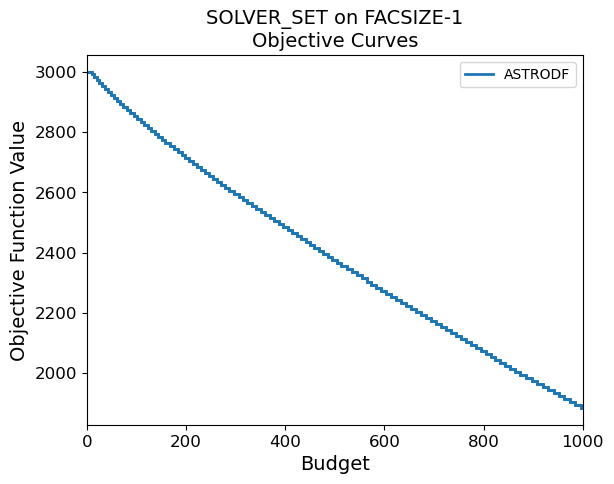

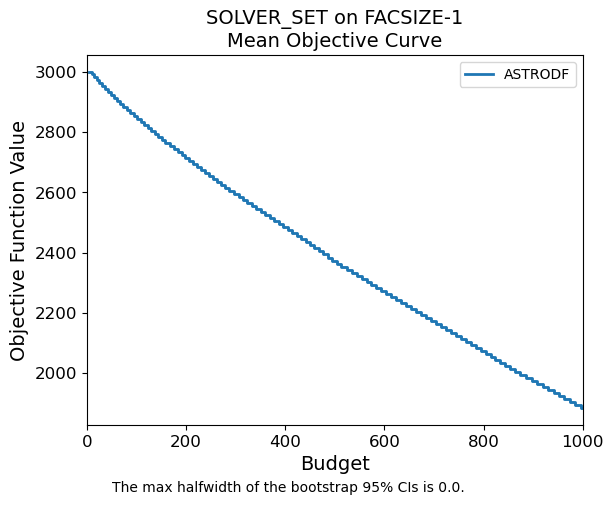

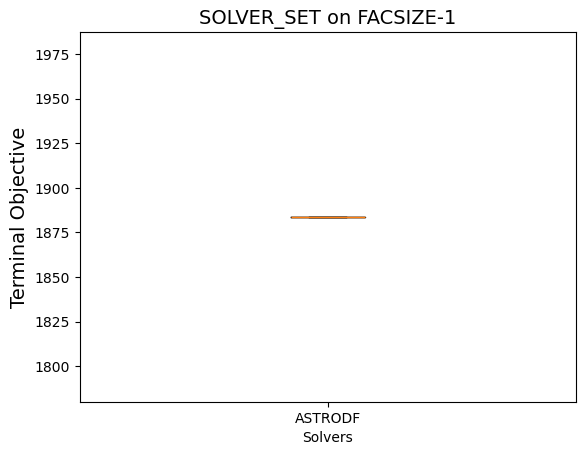

In [7]:
# Produce basic plots.
%matplotlib inline
from simopt.experiment_base import (
    PlotType,
    plot_progress_curves,
    plot_terminal_progress,
    plot_solvability_cdfs,
)

print("Plotting results...")


def _print_path(plot_path: list[Path]) -> None:
    print(f"Plot saved to {plot_path!s}")


_print_path(
    plot_progress_curves(
        experiments=[myexperiment], plot_type=PlotType.ALL, normalize=False
    )
)
_print_path(
    plot_progress_curves(
        experiments=[myexperiment], plot_type=PlotType.MEAN, normalize=False
    )
)

_print_path(
    plot_terminal_progress(
        experiments=[myexperiment], plot_type=PlotType.BOX, normalize=False
    )
)


print("Plotting complete!")